# Entrenamiento de modelos de clasificación

Este notebook documenta el entrenamiento de modelos de clasificación de coberturas.

El proceso incluye:

- carga del split estratificado generado en la etapa anterior;
- entrenamiento de modelos base;
- comparación de métricas;
- visualización mediante radar plot;
- selección del mejor modelo base según F1 macro;
- ajuste de hiperparámetros mediante `RandomizedSearchCV`;
- comparación entre modelo base y modelo optimizado;
- guardado de modelos, métricas y búsqueda de hiperparámetros.

El modelo optimizado será utilizado en las siguientes etapas de evaluación e inferencia espacial.


In [1]:
from pathlib import Path
import sys

import pandas as pd

In [2]:
BASE_DIR = Path.cwd()

while not (BASE_DIR / "src").exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent

sys.path.append(str(BASE_DIR))

print("BASE_DIR detectado:")
print(BASE_DIR)

BASE_DIR detectado:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml


## Importación de funciones auxiliares

La carga del split se realiza desde el módulo de muestras.

El entrenamiento, comparación de modelos, ajuste de hiperparámetros y guardado de resultados se ejecutan con funciones de:

`src/clasificacion_coberturas/entrenamiento.py`


In [3]:
from src.clasificacion_coberturas.muestras import cargar_split_clasificacion

from src.clasificacion_coberturas.entrenamiento import (
    pipeline_entrenamiento_clasificacion
)

## Configuración de rutas

Se definen las rutas del split, modelos, tablas y figuras.

El split debe haber sido generado previamente en `04_preparacion_muestras.ipynb`.


In [4]:
# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

year = 2018

ruta_split = (
    BASE_DIR
    / "data"
    / "interim"
    / "clasificacion_coberturas"
    / "splits"
    / f"split_clasificacion_{year}.joblib"
)

carpeta_modelos = (
    BASE_DIR
    / "models"
    / "clasificacion_coberturas"
)

carpeta_tablas = (
    BASE_DIR
    / "outputs"
    / "tables"
    / "clasificacion_coberturas"
)

carpeta_figuras = (
    BASE_DIR
    / "outputs"
    / "figures"
    / "clasificacion_coberturas"
)

print("Split:")
print(ruta_split)

print("\nCarpeta de modelos:")
print(carpeta_modelos)

print("\nCarpeta de tablas:")
print(carpeta_tablas)

print("\nCarpeta de figuras:")
print(carpeta_figuras)

Split:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\splits\split_clasificacion_2018.joblib

Carpeta de modelos:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\models\clasificacion_coberturas

Carpeta de tablas:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\tables\clasificacion_coberturas

Carpeta de figuras:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\figures\clasificacion_coberturas


## Carga del split

Se carga el split estratificado generado en la preparación de muestras.

Este archivo contiene:

- matrices de entrenamiento y prueba;
- etiquetas de clase;
- variables usadas por el modelo;
- rutas de insumos;
- parámetros de partición.


In [5]:
split_data = cargar_split_clasificacion(ruta_split)

X_train = split_data["X_train"]
X_test = split_data["X_test"]
y_train = split_data["y_train"]
y_test = split_data["y_test"]

variables_modelo = split_data["variables_modelo"]
test_size = split_data["test_size"]
random_state = split_data["random_state"]
columna_clase = split_data["columna_clase"]
columna_clase_nombre = split_data["columna_clase_nombre"]

print("Split cargado correctamente.")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nNúmero de variables:")
print(len(variables_modelo))

print("\nTest size:")
print(test_size)

print("\nRandom state:")
print(random_state)

Split cargado correctamente.
X_train: (140, 22)
X_test: (60, 22)
y_train: (140,)
y_test: (60,)

Número de variables:
22

Test size:
0.3

Random state:
42


## Configuración de entrenamiento

Se define la configuración general del entrenamiento y la búsqueda de hiperparámetros.

La métrica usada para seleccionar el mejor modelo es `f1_macro`, apropiada para clasificación multiclase cuando interesa ponderar de forma equilibrada el desempeño entre clases.


In [6]:
cv_splits = 5
scoring = "f1_macro"
n_jobs = -1
verbose = 1

print("Folds CV:", cv_splits)
print("Scoring:", scoring)
print("n_jobs:", n_jobs)
print("verbose:", verbose)

Folds CV: 5
Scoring: f1_macro
n_jobs: -1
verbose: 1


## Entrenamiento de modelos base y ajuste de hiperparámetros

Se entrenan varios modelos base y se comparan usando el conjunto de prueba.

Después, el mejor modelo base se optimiza mediante `RandomizedSearchCV`.

En esta versión, el escalamiento con `StandardScaler` se aplica únicamente a modelos sensibles a la escala de las variables, como SVM y KNN.


Entrenando modelo: CARTO_base...
Entrenando modelo: RF_base...
Entrenando modelo: SVM_RBF_base...
Entrenando modelo: GB_base...
Entrenando modelo: ExtraTrees_base...
Entrenando modelo: AdaBoost_base...
Entrenando modelo: HistGB_base...
Entrenando modelo: KNN_base...

Mejor modelo base:
CARTO_base


C:\Users\AVDON\anaconda3\envs\humedales_clasificacion\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Modelos base guardados en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\models\clasificacion_coberturas\base
Tabla guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\tables\clasificacion_coberturas\metricas_modelos_base.csv
Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\figures\clasificacion_coberturas\radar_modelos_base.png


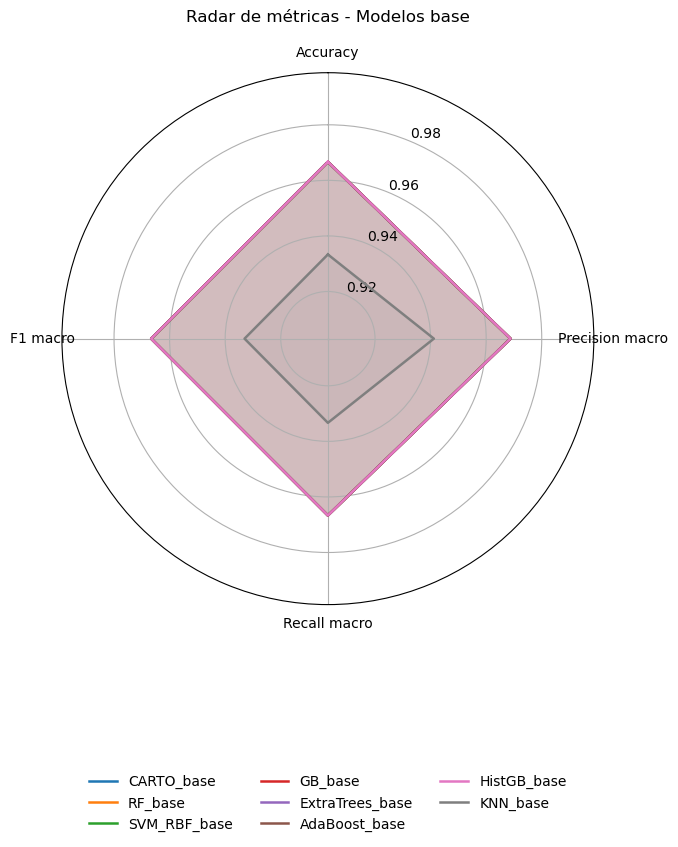

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Archivo guardado en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\models\clasificacion_coberturas\busqueda_modelo_tuning.joblib
Archivo guardado en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\models\clasificacion_coberturas\modelo_clasificacion_tuning.joblib
Tabla guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\tables\clasificacion_coberturas\comparacion_base_tuning.csv
Entrenamiento completado.


In [7]:
resultados_entrenamiento = pipeline_entrenamiento_clasificacion(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    carpeta_modelos=carpeta_modelos,
    carpeta_tablas=carpeta_tablas,
    carpeta_figuras=carpeta_figuras,
    random_state=random_state,
    cv_splits=cv_splits,
    scoring=scoring,
    n_jobs=n_jobs,
    verbose=verbose
)

df_resultados = resultados_entrenamiento["df_resultados"]
mejor_nombre = resultados_entrenamiento["mejor_nombre"]
search = resultados_entrenamiento["search"]
mejor_modelo_tuning = resultados_entrenamiento["mejor_modelo_tuning"]
tabla_comparacion = resultados_entrenamiento["tabla_comparacion"]

print("Entrenamiento completado.")

## Métricas de modelos base

La siguiente tabla muestra el desempeño de los modelos base, ordenados por F1 macro.


In [8]:
display(df_resultados)

print("Mejor modelo base:")
print(mejor_nombre)

,accuracy,precision_macro,recall_macro,f1_macro
CARTO_base,0.966667,0.968750,0.966667,0.966630
RF_base,0.966667,0.968750,0.966667,0.966630
SVM_RBF_base,0.966667,0.968750,0.966667,0.966630
GB_base,0.966667,0.968750,0.966667,0.966630
ExtraTrees_base,0.966667,0.968750,0.966667,0.966630
AdaBoost_base,0.966667,0.968750,0.966667,0.966630
HistGB_base,0.966667,0.968750,0.966667,0.966630
KNN_base,0.933333,0.941176,0.933333,0.933036


Mejor modelo base:
CARTO_base


## Mejores hiperparámetros

Se reportan los mejores hiperparámetros encontrados para el modelo optimizado.


In [9]:
print("Mejores hiperparámetros:")
print(search.best_params_)

print("\nMejor score CV:")
print(search.best_score_)

Mejores hiperparámetros:
{'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15, 'criterion': 'gini'}

Mejor score CV:
0.9713370665094804


## Comparación base vs modelo optimizado

Se compara el mejor modelo base contra su versión optimizada mediante búsqueda de hiperparámetros.

La evaluación posterior y la clasificación espacial usarán el modelo optimizado.


In [10]:
display(tabla_comparacion)

,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro
0,CARTO_base,0.966667,0.96875,0.966667,0.96663
1,CARTO_tuning,0.966667,0.96875,0.966667,0.96663


## Producto de esta etapa

Al finalizar este notebook se generan:

- modelos base entrenados;
- modelo optimizado;
- objeto de búsqueda de hiperparámetros;
- tabla de métricas de modelos base;
- tabla comparativa entre modelo base y modelo optimizado;
- radar plot de comparación de modelos.

Los modelos se guardan en:

`models/clasificacion_coberturas/`

Las tablas se guardan en:

`outputs/tables/clasificacion_coberturas/`

Las figuras se guardan en:

`outputs/figures/clasificacion_coberturas/`

## Siguiente etapa del flujo

Una vez entrenado el modelo optimizado, el siguiente paso consiste en evaluar detalladamente su desempeño mediante matriz de confusión, reporte de clasificación e importancia por permutación.

Esta fase se documenta en:

`06_evaluacion_modelos.ipynb`
